# Advanced Statistical Analysis & Hypothesis Testing

**Research question:** Does study time have a significant relationship with students' academic performance?

**Dataset:** Synthetic student performance data (100 records).

**Alpha level:** 0.05

This notebook performs:
- Shapiro-Wilk and Kolmogorov-Smirnov normality tests
- Independent two-sample t-test
- Mann-Whitney U test
- One-Way ANOVA
- Tukey HSD post-hoc analysis
- Two-Way ANOVA
- Distribution plots
- Hypotheses, confidence intervals, and findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Upload the dataset in Google Colab
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("student_performance_synthetic.csv")
df.head()

Saving student_performance_synthetic.csv to student_performance_synthetic.csv


,Student_ID,Study_Time_Hours,Attendance_Percent,Previous_Marks,Final_Marks
0,S001,4,91,67,55
1,S002,5,95,70,51
2,S003,3,91,55,50
3,S004,5,94,83,71
4,S005,5,86,84,66


In [2]:
print("Number of records:", len(df))
print("\nColumns:")
print(df.columns.tolist())
print("\nSummary statistics:")
display(df.describe())

Number of records: 100

Columns:
['Student_ID', 'Study_Time_Hours', 'Attendance_Percent', 'Previous_Marks', 'Final_Marks']

Summary statistics:


,Study_Time_Hours,Attendance_Percent,Previous_Marks,Final_Marks
count,100.000000,100.000000,100.000000,100.000000
mean,3.690000,85.910000,70.980000,54.840000
std,1.624901,8.343745,8.965681,9.289638
min,1.000000,61.000000,50.000000,35.000000
25%,2.000000,79.750000,64.750000,48.000000
50%,4.000000,85.000000,70.500000,54.000000
75%,5.000000,93.000000,77.250000,62.250000
max,6.000000,100.000000,93.000000,74.000000


## 1. Normality Tests

**Null hypothesis (H0):** The sample comes from a normally distributed population.

**Alternative hypothesis (H1):** The sample does not come from a normally distributed population.

For the Kolmogorov-Smirnov test, each variable is standardized before comparison with the standard normal distribution. A p-value below 0.05 indicates evidence against normality.

In [3]:
variables = ["Study_Time_Hours", "Final_Marks"]

for col in variables:
    x = df[col].dropna()
    shapiro_stat, shapiro_p = stats.shapiro(x)
    z = (x - x.mean()) / x.std(ddof=1)
    ks_stat, ks_p = stats.kstest(z, "norm")

    print(f"--- {col} ---")
    print("Shapiro-Wilk statistic:", round(shapiro_stat, 4))
    print("Shapiro-Wilk p-value:", f"{shapiro_p:.6f}")
    print("Kolmogorov-Smirnov statistic:", round(ks_stat, 4))
    print("Kolmogorov-Smirnov p-value:", f"{ks_p:.6f}")
    print()

--- Study_Time_Hours ---
Shapiro-Wilk statistic: 0.9117
Shapiro-Wilk p-value: 0.000005
Kolmogorov-Smirnov statistic: 0.1657
Kolmogorov-Smirnov p-value: 0.007243

--- Final_Marks ---
Shapiro-Wilk statistic: 0.9775
Shapiro-Wilk p-value: 0.084614
Kolmogorov-Smirnov statistic: 0.0852
Kolmogorov-Smirnov p-value: 0.438266



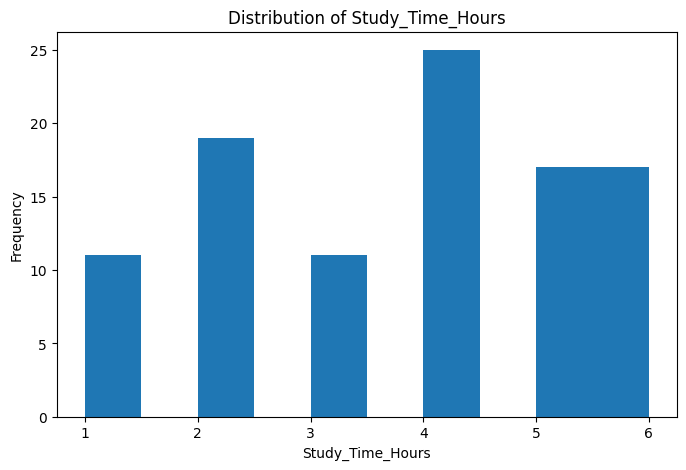

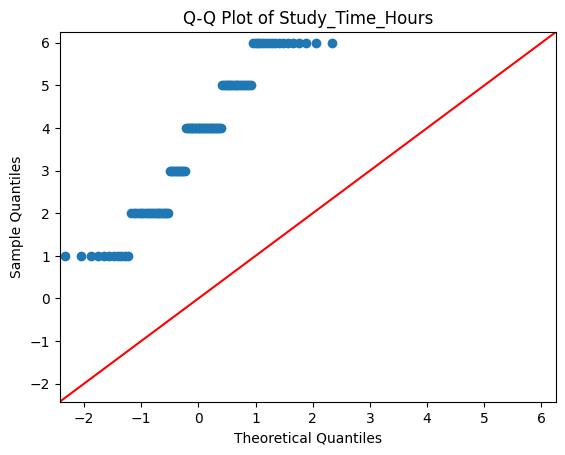

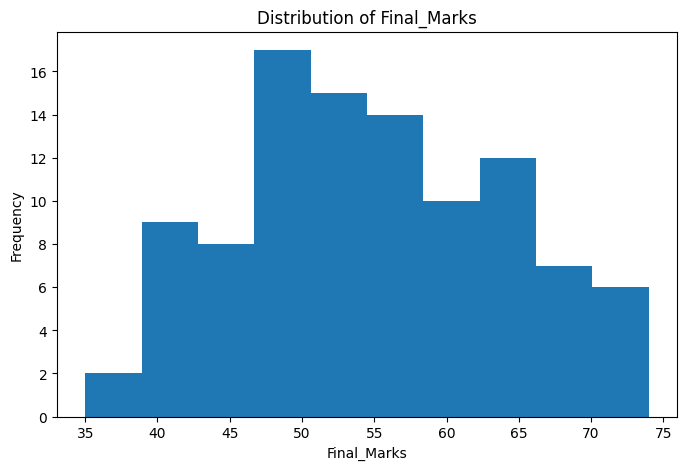

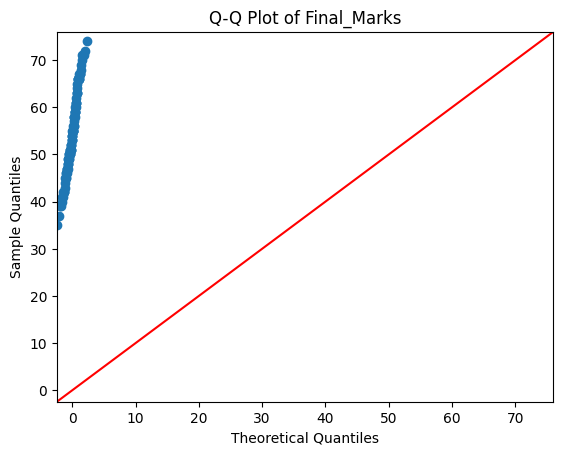

In [4]:
# Distribution plots and Q-Q plots
for col in variables:
    x = df[col].dropna()

    fig = plt.figure(figsize=(8, 5))
    plt.hist(x, bins=10)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()

    sm.qqplot(x, line="45")
    plt.title(f"Q-Q Plot of {col}")
    plt.show()

## 2. Two-Sample t-Test and Mann-Whitney U Test

To compare two groups, students are divided into:
- **Low study time:** 1–3 hours
- **High study time:** 4–6 hours

### Independent t-test
**H0:** The mean final marks are equal between the two study-time groups.

**H1:** The mean final marks are different between the two study-time groups.

### Mann-Whitney U test
**H0:** The two groups have the same distribution of final marks.

**H1:** The distributions of final marks differ between the two groups.

A 95% confidence interval for the difference in group means is also calculated.

In [5]:
df["Study_Group"] = np.where(
    df["Study_Time_Hours"] <= 3,
    "Low Study Time (1-3h)",
    "High Study Time (4-6h)"
)

low = df.loc[df["Study_Group"] == "Low Study Time (1-3h)", "Final_Marks"].dropna()
high = df.loc[df["Study_Group"] == "High Study Time (4-6h)", "Final_Marks"].dropna()

# Welch's independent two-sample t-test
t_stat, t_p = stats.ttest_ind(low, high, equal_var=False)

# 95% CI for (high-study mean - low-study mean)
mean_diff = high.mean() - low.mean()
se_diff = np.sqrt(high.var(ddof=1)/len(high) + low.var(ddof=1)/len(low))
df_welch = (high.var(ddof=1)/len(high) + low.var(ddof=1)/len(low))**2 / (
    (high.var(ddof=1)/len(high))**2/(len(high)-1) +
    (low.var(ddof=1)/len(low))**2/(len(low)-1)
)
t_crit = stats.t.ppf(0.975, df_welch)
ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

u_stat, u_p = stats.mannwhitneyu(low, high, alternative="two-sided")

print("Low-study group mean:", round(low.mean(), 3))
print("High-study group mean:", round(high.mean(), 3))
print("Mean difference (high - low):", round(mean_diff, 3))
print("95% CI for mean difference:", (round(ci_low, 3), round(ci_high, 3)))
print("Welch t-statistic:", round(t_stat, 3))
print("Welch t-test p-value:", f"{t_p:.6g}")
print("Mann-Whitney U statistic:", round(u_stat, 3))
print("Mann-Whitney U p-value:", f"{u_p:.6g}")

Low-study group mean: 47.854
High-study group mean: 59.695
Mean difference (high - low): 11.841
95% CI for mean difference: (np.float64(9.015), np.float64(14.668))
Welch t-statistic: -8.317
Welch t-test p-value: 6.41251e-13
Mann-Whitney U statistic: 294.5
Mann-Whitney U p-value: 1.41491e-10


## 3. One-Way ANOVA

Students are compared across all six study-time groups (1, 2, 3, 4, 5, and 6 hours).

**H0:** Mean final marks are equal across all study-time groups.

**H1:** At least one study-time group has a different mean final mark.

If ANOVA is significant, Tukey HSD is used to identify which pairs differ.

In [6]:
groups = [
    df.loc[df["Study_Time_Hours"] == hour, "Final_Marks"].dropna()
    for hour in sorted(df["Study_Time_Hours"].unique())
]

f_stat, anova_p = stats.f_oneway(*groups)

anova_model = ols("Final_Marks ~ C(Study_Time_Hours)", data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

print("One-Way ANOVA F-statistic:", round(f_stat, 3))
print("One-Way ANOVA p-value:", f"{anova_p:.6g}")
display(anova_table)

One-Way ANOVA F-statistic: 22.728
One-Way ANOVA p-value: 6.97098e-15


,sum_sq,df,F,PR(>F)
C(Study_Time_Hours),4675.806699,5.0,22.728413,6.970984e-15
Residual,3867.633301,94.0,NaN,NaN


In [7]:
# Tukey HSD post-hoc test
tukey = pairwise_tukeyhsd(
    endog=df["Final_Marks"],
    groups=df["Study_Time_Hours"],
    alpha=0.05
)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   2.8278 0.8529 -4.2426  9.8981  False
     1      3   6.0909 0.2355 -1.8665 14.0483  False
     1      4   9.8109 0.0008  3.0588  16.563   True
     1      5  18.0321    0.0 10.8108 25.2533   True
     1      6  18.8556    0.0 11.6344 26.0769   True
     2      3   3.2632 0.7604 -3.8072 10.3335  False
     2      4   6.9832 0.0071  1.3033  12.663   True
     2      5  15.2043    0.0  8.9741 21.4346   True
     2      6  16.0279    0.0  9.7976 22.2581   True
     3      4     3.72 0.5987 -3.0321 10.4721  False
     3      5  11.9412 0.0001  4.7199 19.1624   True
     3      6  12.7647    0.0  5.5435  19.986   True
     4      5   8.2212 0.0013  2.3546 14.0877   True
     4      6   9.0447 0.0003  3.1781 14.9113   True
     5      6   0.8235  0.999 -5.5774  7.2245  False
----------------------------------------------

## 4. Two-Way ANOVA

Two factors are used:
- **Study Group:** Low (1–3 hours) vs High (4–6 hours)
- **Attendance Group:** Low (<85%) vs High (>=85%)

**Study-group H0:** Study group has no effect on final marks.

**Attendance-group H0:** Attendance group has no effect on final marks.

**Interaction H0:** There is no interaction between study group and attendance group.

A p-value below 0.05 indicates a statistically significant main effect or interaction.

In [8]:
df["Attendance_Group"] = np.where(
    df["Attendance_Percent"] < 85,
    "Low Attendance (<85%)",
    "High Attendance (>=85%)"
)

print("Group counts:")
display(pd.crosstab(df["Study_Group"], df["Attendance_Group"]))

two_way_model = ols(
    "Final_Marks ~ C(Study_Group) * C(Attendance_Group)",
    data=df
).fit()

two_way_table = sm.stats.anova_lm(two_way_model, typ=2)
display(two_way_table)

Group counts:


Attendance_Group,High Attendance (>=85%),Low Attendance (<85%)
Study_Group,,
High Study Time (4-6h),42,17
Low Study Time (1-3h),12,29


,sum_sq,df,F,PR(>F)
C(Study_Group),1931.224190,1.0,39.722149,8.874347e-09
C(Attendance_Group),481.513231,1.0,9.903946,2.197089e-03
C(Study_Group):C(Attendance_Group),2.758337,1.0,0.056735,8.122413e-01
Residual,4667.358857,96.0,NaN,NaN


## 5. Findings and Interpretation

Using **alpha = 0.05**:

- The t-test and Mann-Whitney U test evaluate whether low- and high-study-time groups differ.
- One-Way ANOVA evaluates differences across all six study-time groups.
- Tukey HSD identifies the specific study-time pairs with significant differences.
- Two-Way ANOVA evaluates the effects of study time, attendance, and their interaction.

Because this is a **synthetic dataset**, the findings demonstrate the statistical workflow and should not be interpreted as evidence about real students.

In [9]:
print("=== FINAL STATISTICAL SUMMARY ===")
print("Sample size:", len(df))
print("Alpha:", 0.05)

print("\nTwo-sample tests:")
print("Welch t-test p-value:", f"{t_p:.6g}")
print("Mann-Whitney U p-value:", f"{u_p:.6g}")
print("95% CI for high-study minus low-study mean:", (round(ci_low,3), round(ci_high,3)))

print("\nOne-Way ANOVA:")
print("F-statistic:", round(f_stat,3))
print("p-value:", f"{anova_p:.6g}")

print("\nTwo-Way ANOVA p-values:")
print(two_way_table["PR(>F)"])

print("\nConclusion:")
if t_p < 0.05 and u_p < 0.05 and anova_p < 0.05:
    print("Study-time groups show statistically significant differences in final marks.")
else:
    print("Not all study-time comparisons are statistically significant.")

print("The analysis uses synthetic data and is intended as a reproducible statistical example.")

=== FINAL STATISTICAL SUMMARY ===
Sample size: 100
Alpha: 0.05

Two-sample tests:
Welch t-test p-value: 6.41251e-13
Mann-Whitney U p-value: 1.41491e-10
95% CI for high-study minus low-study mean: (np.float64(9.015), np.float64(14.668))

One-Way ANOVA:
F-statistic: 22.728
p-value: 6.97098e-15

Two-Way ANOVA p-values:
C(Study_Group)                        8.874347e-09
C(Attendance_Group)                   2.197089e-03
C(Study_Group):C(Attendance_Group)    8.122413e-01
Residual                                       NaN
Name: PR(>F), dtype: float64

Conclusion:
Study-time groups show statistically significant differences in final marks.
The analysis uses synthetic data and is intended as a reproducible statistical example.
